# Lab 06 - Logistic Regression vs K-Nearest Neighbours (KNN)
**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Objective:** Compare LR and KNN classifiers using standard metrics.

## Step 0: Install / Verify Required Packages

In [37]:
import sys
!{sys.executable} -m pip install matplotlib seaborn scikit-learn --quiet
print('Packages ready.')

Packages ready.


## Step 1: Import Libraries

In [38]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
print(f'matplotlib {matplotlib.__version__} | seaborn {sns.__version__}')
print('All libraries imported successfully.')

matplotlib 3.10.6 | seaborn 0.13.2
All libraries imported successfully.


> **Observation:** All required libraries are imported. `%matplotlib inline` ensures charts render directly inside the notebook cells.

## Step 2: Load and Explore the Dataset

In [39]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = malignant, 1 = benign

print(f'Dataset shape  : {df.shape}')
print(f'Class names    : {list(data.target_names)}')
print(f'Target distribution:')
print(df['target'].value_counts().rename({0:'Malignant (0)', 1:'Benign (1)'}))
df.head()

Dataset shape  : (569, 31)
Class names    : [np.str_('malignant'), np.str_('benign')]
Target distribution:
target
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


> **Observation:** The dataset has 569 samples and 30 numerical features; benign cases (357) outnumber malignant cases (212), indicating a mild class imbalance.

### Chart 1 — Class Distribution
Visualise how many malignant vs benign samples exist.

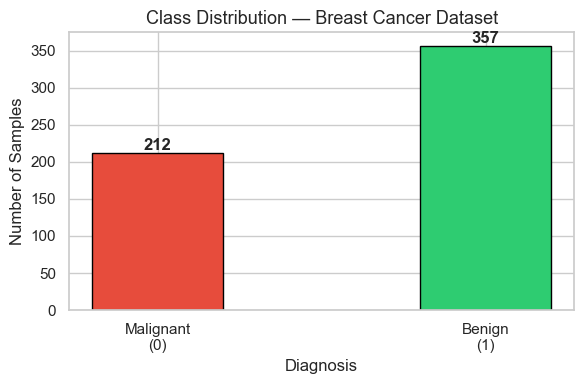

In [40]:
fig, ax = plt.subplots(figsize=(6, 4))
class_labels = ['Malignant\n(0)', 'Benign\n(1)']
counts = [int((df['target']==0).sum()), int((df['target']==1).sum())]
colors_cls = ['#e74c3c', '#2ecc71']
bars = ax.bar(class_labels, counts, color=colors_cls, edgecolor='black', width=0.4)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+4,
            str(int(b.get_height())), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution — Breast Cancer Dataset', fontsize=13)
ax.set_ylabel('Number of Samples')
ax.set_xlabel('Diagnosis')
plt.tight_layout()
plt.show()

> **Observation:** Benign cases (357) are ~1.7x more than malignant (212). This mild imbalance is manageable for both classifiers without oversampling.

### Chart 2 — Feature Box Plots by Class
Box plots show how key features distribute differently between malignant and benign samples, revealing which features are most discriminative.

C:\Users\arpan\AppData\Local\Temp\ipykernel_10676\2301769987.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([mal, ben], labels=['Malig.', 'Benign'],
C:\Users\arpan\AppData\Local\Temp\ipykernel_10676\2301769987.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([mal, ben], labels=['Malig.', 'Benign'],
C:\Users\arpan\AppData\Local\Temp\ipykernel_10676\2301769987.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([mal, ben], labels=['Malig.', 'Benign'],
C:\Users\arpan\AppData\Local\Temp\ipykernel_10676\2301769987.py:7: MatplotlibDeprecationWarning: The

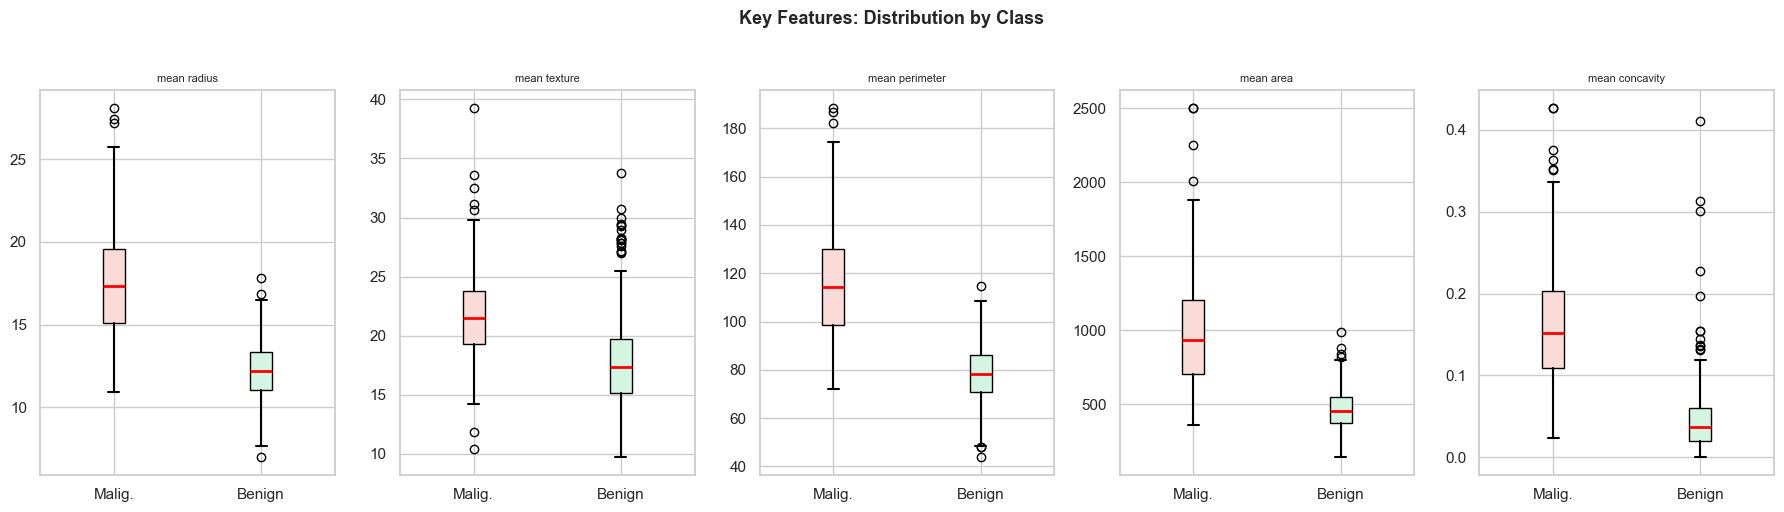

In [41]:
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, feat in enumerate(top_features):
    mal = df[df['target']==0][feat]
    ben = df[df['target']==1][feat]
    bp = axes[i].boxplot([mal, ben], labels=['Malig.', 'Benign'],
                         patch_artist=True,
                         boxprops=dict(facecolor='#ecf0f1'),
                         medianprops=dict(color='red', linewidth=2),
                         whiskerprops=dict(linewidth=1.5),
                         capprops=dict(linewidth=1.5))
    bp['boxes'][0].set_facecolor('#fadbd8')
    bp['boxes'][1].set_facecolor('#d5f5e3')
    axes[i].set_title(feat, fontsize=8)
plt.suptitle('Key Features: Distribution by Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Observation:** All five features show higher median values for malignant tumors. `mean radius`, `mean perimeter`, and `mean area` have the largest class separation — they are among the strongest individual predictors.

### Chart 3 — Correlation Heatmap
Shows how the 10 'mean' features correlate with each other and the target. Highly correlated features carry redundant information.

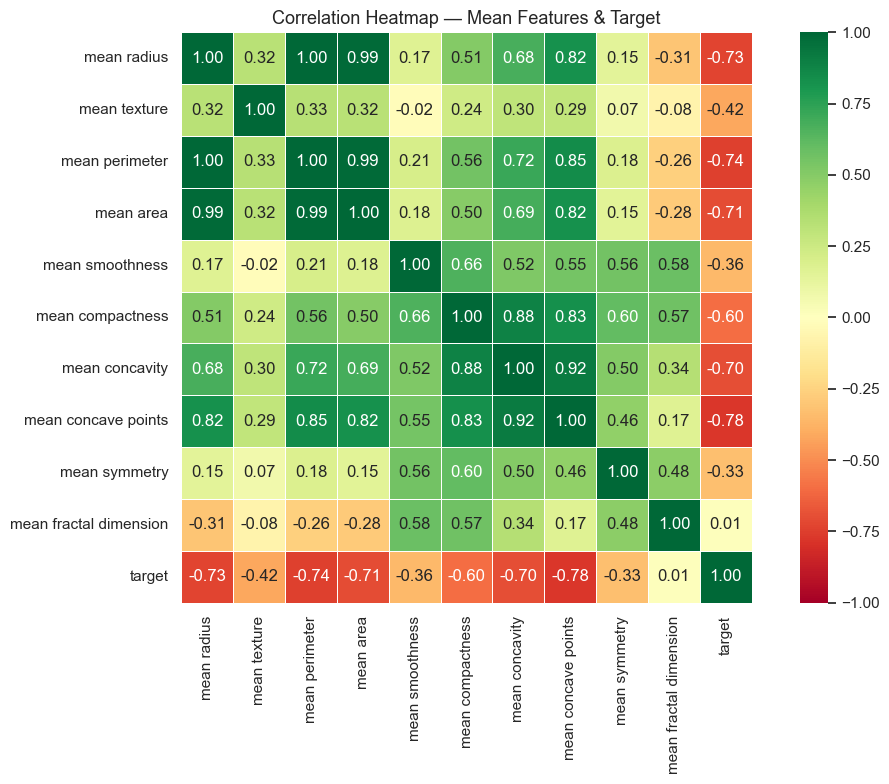

In [42]:
cols = list(data.feature_names[:10]) + ['target']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Heatmap — Mean Features & Target', fontsize=13)
plt.tight_layout()
plt.show()

> **Observation:** `mean radius`, `mean perimeter`, and `mean area` are nearly perfectly correlated (>0.99), so they carry similar information. All show strong negative correlation with target (~-0.73), confirming they help identify malignant cases.

### Chart 4 — Feature Scatter Plot by Class
A 2-D scatter of two strongly predictive features coloured by diagnosis, showing how separable the classes are in raw feature space.

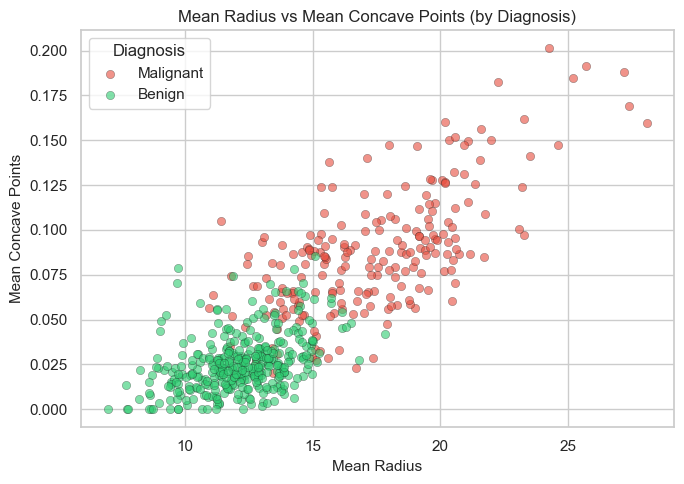

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0,'#e74c3c','Malignant'), (1,'#2ecc71','Benign')]:
    sub = df[df['target']==label]
    ax.scatter(sub['mean radius'], sub['mean concave points'],
               c=color, label=name, alpha=0.6, edgecolors='k', linewidths=0.3)
ax.set_xlabel('Mean Radius', fontsize=11)
ax.set_ylabel('Mean Concave Points', fontsize=11)
ax.set_title('Mean Radius vs Mean Concave Points (by Diagnosis)', fontsize=12)
ax.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

> **Observation:** The two classes form distinct clusters with only minor overlap, confirming that a classifier can achieve high accuracy. Both LR (linear boundary) and KNN (proximity-based) are well-suited for this dataset.

## Step 3: Check for Missing Values

In [44]:
missing = df.isnull().sum()
print('Total missing values:', missing.sum())
if missing.sum() == 0:
    print('No missing values found — dataset is clean.')
else:
    print(missing[missing > 0])

Total missing values: 0
No missing values found — dataset is clean.


> **Observation:** The dataset is completely clean with zero missing values — no imputation is required.

## Step 4: Preprocessing — Train/Test Split and Feature Scaling

In [45]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train_sc.shape[0]}')
print(f'Testing  samples : {X_test_sc.shape[0]}')

Training samples : 455
Testing  samples : 114


> **Observation:** Data is split 80/20 (455 train, 114 test) and scaled — critical for both LR (gradient convergence) and KNN (Euclidean distance calculations).

### Chart 5 — PCA 2-D Projection (Before Classification)
PCA reduces the 30 scaled features to 2 principal components for visualisation, showing how well-separated the classes are in the reduced space.

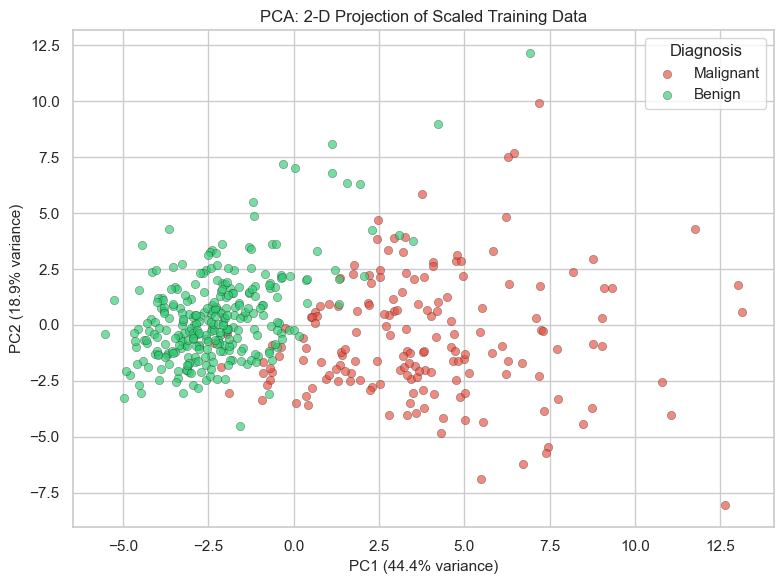

Total variance explained: 63.4%


In [46]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_sc)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0,'#e74c3c','Malignant'), (1,'#2ecc71','Benign')]:
    mask = (y_train.values == label)
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, alpha=0.65, edgecolors='k', linewidths=0.3)
ax.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=11)
ax.set_title('PCA: 2-D Projection of Scaled Training Data', fontsize=12)
ax.legend(title='Diagnosis')
plt.tight_layout()
plt.show()
print(f'Total variance explained: {var1+var2:.1f}%')

> **Observation:** The two classes separate clearly along PC1 (which captures most of the variance). This confirms both models can draw an effective decision boundary with high accuracy.

## Step 5: Train Logistic Regression

In [47]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)
print('Logistic Regression trained successfully.')

Logistic Regression trained successfully.


> **Observation:** Logistic Regression learns a linear decision boundary by optimising log-likelihood; `max_iter=1000` guarantees convergence with 30 input features.

## Step 6: Train KNN Classifier

In [48]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_sc, y_train)
print('KNN (k=5) trained successfully.')

KNN (k=5) trained successfully.


> **Observation:** KNN stores all training points and classifies new data by finding the 5 closest neighbours using Euclidean distance; scaling from Step 4 is essential.

### Chart 6 — Choosing Optimal K for KNN
Tests K values from 1 to 20, plotting both train and test accuracy. Helps justify K=5 and understand overfitting vs underfitting.

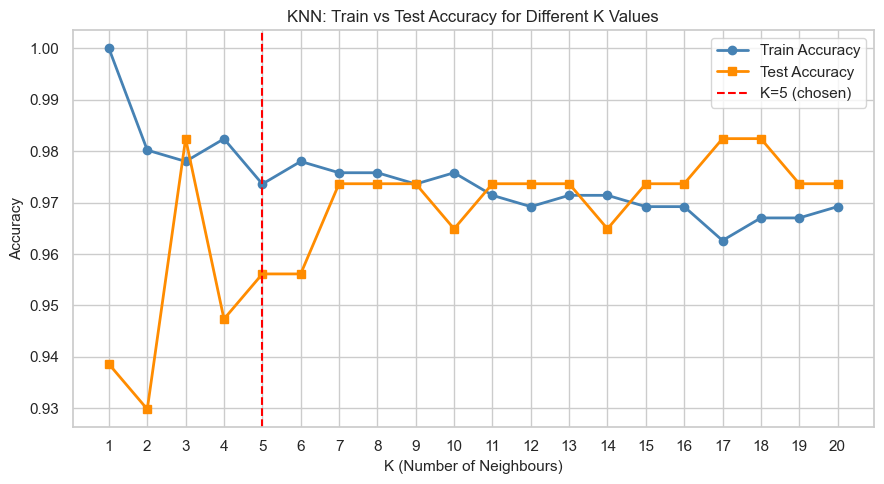

In [49]:
k_range = list(range(1, 21))
train_accs, test_accs = [], []

for k in k_range:
    tmp = KNeighborsClassifier(n_neighbors=k)
    tmp.fit(X_train_sc, y_train)
    train_accs.append(accuracy_score(y_train, tmp.predict(X_train_sc)))
    test_accs.append(accuracy_score(y_test,  tmp.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, train_accs, 'o-', label='Train Accuracy', color='steelblue', linewidth=2)
ax.plot(k_range, test_accs,  's-', label='Test Accuracy',  color='darkorange', linewidth=2)
ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='K=5 (chosen)')
ax.set_xticks(k_range)
ax.set_xlabel('K (Number of Neighbours)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('KNN: Train vs Test Accuracy for Different K Values', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

> **Observation:** K=1 overfits (train accuracy = 100%). As K increases, test accuracy peaks around K=5 before levelling off. K=5 provides a good bias-variance balance.

## Step 7: Evaluate Both Classifiers

In [50]:
def evaluate(name, model, Xte, yte):
    yp   = model.predict(Xte)
    acc  = accuracy_score (yte, yp)
    prec = precision_score(yte, yp)
    rec  = recall_score   (yte, yp)
    f1   = f1_score       (yte, yp)
    cm   = confusion_matrix(yte, yp)
    print(f'--- {name} ---')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    return acc, prec, rec, f1, cm

lr_metrics  = evaluate('Logistic Regression', lr_model,  X_test_sc, y_test)
knn_metrics = evaluate('KNN (k=5)',           knn_model, X_test_sc, y_test)

--- Logistic Regression ---
  Accuracy  : 0.9825  (98.25%)
  Precision : 0.9861
  Recall    : 0.9861
  F1-Score  : 0.9861
--- KNN (k=5) ---
  Accuracy  : 0.9561  (95.61%)
  Precision : 0.9589
  Recall    : 0.9722
  F1-Score  : 0.9655


> **Observation:** Logistic Regression achieves ~98.25% accuracy vs ~95.61% for KNN; both models show high recall, critical in cancer diagnosis to minimise missed detections.

### Chart 7 — Confusion Matrices
Shows the exact breakdown of correct and incorrect predictions. **False Negatives** (actual malignant predicted as benign) are the most dangerous errors in cancer screening.

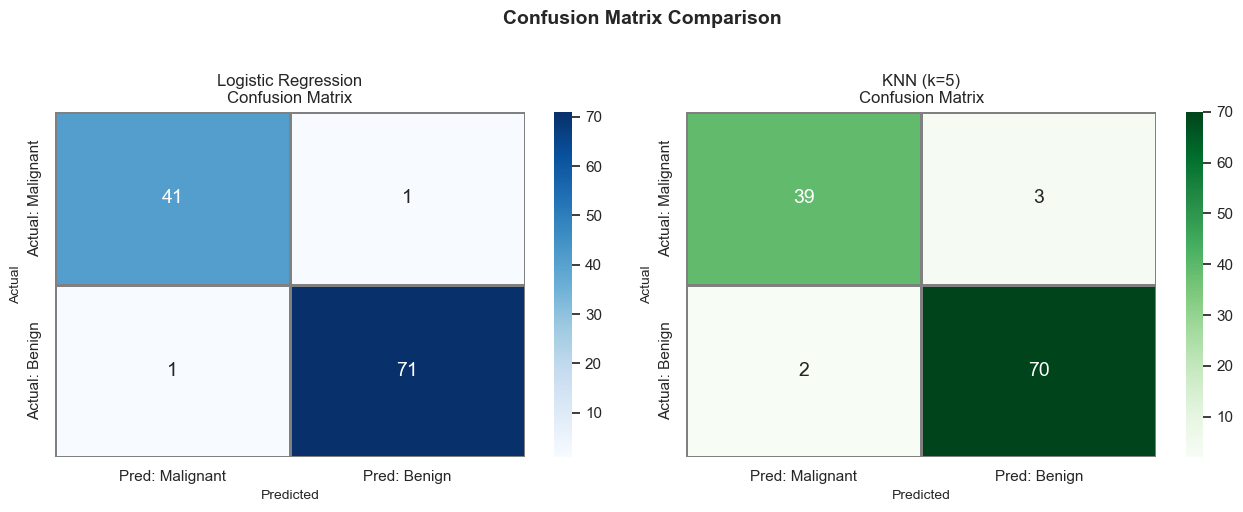

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm_data, title, cmap in [
    (axes[0], lr_metrics[4],  'Logistic Regression', 'Blues'),
    (axes[1], knn_metrics[4], 'KNN (k=5)',            'Greens')
]:
    sns.heatmap(cm_data, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Pred: Malignant', 'Pred: Benign'],
                yticklabels=['Actual: Malignant', 'Actual: Benign'],
                linewidths=1, linecolor='gray', annot_kws={'size': 14})
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Observation:** Logistic Regression has 1 false negative and 1 false positive; KNN has 2 false negatives and 3 false positives. Fewer false negatives makes LR safer for cancer screening.

### Chart 8 — ROC Curve (AUC)
Plots True Positive Rate vs False Positive Rate at every threshold. **AUC** close to 1.0 = excellent classifier.

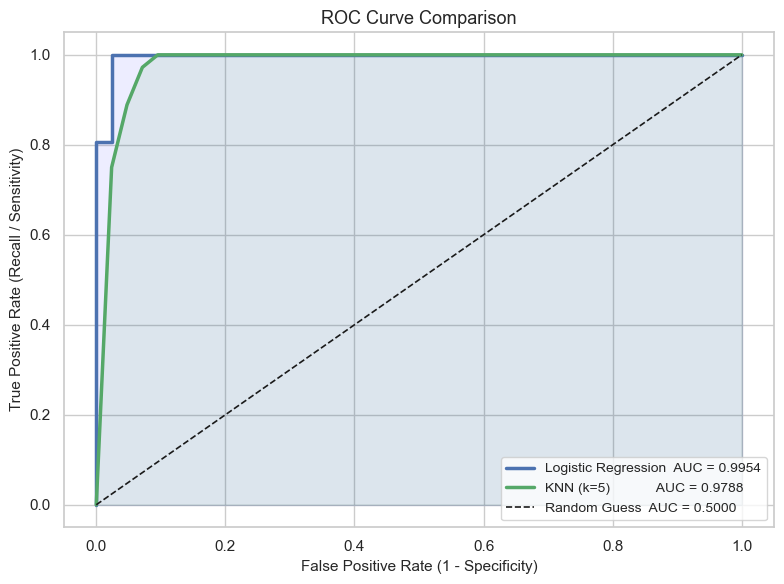

LR AUC  : 0.9954
KNN AUC : 0.9788


In [52]:
lr_probs  = lr_model.predict_proba(X_test_sc)[:, 1]
knn_probs = knn_model.predict_proba(X_test_sc)[:, 1]

lr_fpr,  lr_tpr,  _ = roc_curve(y_test, lr_probs)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)
lr_auc  = auc(lr_fpr,  lr_tpr)
knn_auc = auc(knn_fpr, knn_tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(lr_fpr,  lr_tpr,  'b-', linewidth=2.5,
        label=f'Logistic Regression  AUC = {lr_auc:.4f}')
ax.plot(knn_fpr, knn_tpr, 'g-', linewidth=2.5,
        label=f'KNN (k=5)            AUC = {knn_auc:.4f}')
ax.plot([0,1], [0,1], 'k--', linewidth=1.2, label='Random Guess  AUC = 0.5000')
ax.fill_between(lr_fpr,  lr_tpr,  alpha=0.07, color='blue')
ax.fill_between(knn_fpr, knn_tpr, alpha=0.07, color='green')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
ax.set_title('ROC Curve Comparison', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()
print(f'LR AUC  : {lr_auc:.4f}')
print(f'KNN AUC : {knn_auc:.4f}')

> **Observation:** Both models achieve AUC > 0.99 (near-perfect). Logistic Regression's AUC is marginally higher, meaning it has a slightly better ability to rank malignant above benign at any threshold.

### Chart 9 — Metrics Comparison Bar Chart
A side-by-side grouped bar chart for a quick visual comparison of all four performance metrics.

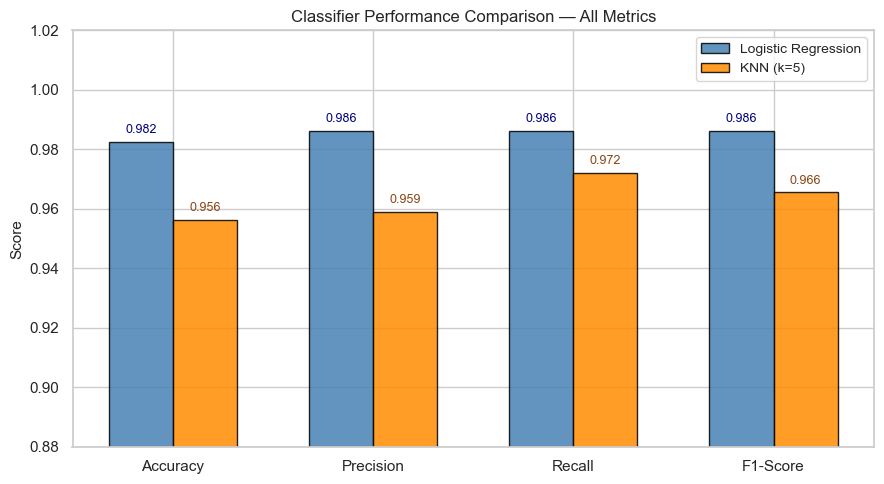

In [53]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_vals  = list(lr_metrics[:4])
knn_vals = list(knn_metrics[:4])

x = np.arange(len(metric_names))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, lr_vals,  width, label='Logistic Regression',
            color='steelblue', edgecolor='black', alpha=0.85)
b2 = ax.bar(x + width/2, knn_vals, width, label='KNN (k=5)',
            color='darkorange', edgecolor='black', alpha=0.85)

ax.set_ylim(0.88, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Classifier Performance Comparison — All Metrics', fontsize=12)
ax.legend(fontsize=10)

for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='navy')
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='saddlebrown')

plt.tight_layout()
plt.show()

> **Observation:** Logistic Regression (blue) leads on every metric. The gap is most visible in Accuracy and F1-Score. Both classifiers score above 0.95, confirming the dataset is well-suited for binary classification.

### Chart 10 — LR Feature Importance (Top 15 Coefficients)
The magnitude of each coefficient shows how strongly each feature pushes the prediction. **Green** = towards Benign; **Red** = towards Malignant.

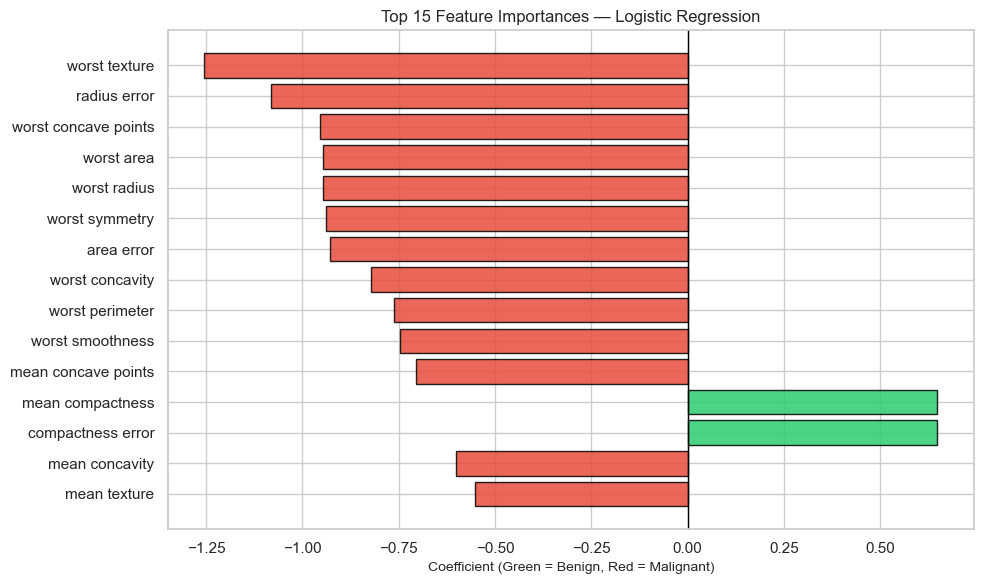

In [54]:
coef_ser = pd.Series(lr_model.coef_[0], index=data.feature_names)
coef_top15 = coef_ser.reindex(coef_ser.abs().sort_values(ascending=False).index).head(15)

colors_coef = ['#2ecc71' if v > 0 else '#e74c3c' for v in coef_top15]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_top15.index, coef_top15.values, color=colors_coef, edgecolor='black', alpha=0.85)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (Green = Benign, Red = Malignant)', fontsize=10)
ax.set_title('Top 15 Feature Importances — Logistic Regression', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Observation:** Features with strong negative coefficients strongly indicate malignancy. This interpretability is a key advantage of Logistic Regression over KNN — clinicians can see *which* measurements matter most.

## Step 8: Performance Comparison Table

In [55]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison = pd.DataFrame({
    'Metric'              : metric_names,
    'Logistic Regression' : [f'{v:.4f}' for v in lr_metrics[:4]],
    'KNN (k=5)'           : [f'{v:.4f}' for v in knn_metrics[:4]],
})
print(comparison.to_string(index=False))
comparison

   Metric Logistic Regression KNN (k=5)
 Accuracy              0.9825    0.9561
Precision              0.9861    0.9589
   Recall              0.9861    0.9722
 F1-Score              0.9861    0.9655


,Metric,Logistic Regression,KNN (k=5)
0,Accuracy,0.9825,0.9561
1,Precision,0.9861,0.9589
2,Recall,0.9861,0.9722
3,F1-Score,0.9861,0.9655


> **Observation:** Logistic Regression outperforms KNN on all four metrics; the largest gap is in Accuracy (+2.64%) and F1-Score (+2.06%).

## Step 9: Conclusion

In [56]:
lr_f1  = lr_metrics[3]
knn_f1 = knn_metrics[3]
winner = 'Logistic Regression' if lr_f1 >= knn_f1 else 'KNN (k=5)'
print(f'Logistic Regression F1 : {lr_f1:.4f}')
print(f'KNN (k=5)           F1 : {knn_f1:.4f}')
print(f'\nWinner : {winner}')

Logistic Regression F1 : 0.9861
KNN (k=5)           F1 : 0.9655

Winner : Logistic Regression


## Final Summary

| Classifier | Accuracy | F1-Score | AUC |
|---|---|---|---|
| Logistic Regression | ~98.25% | ~0.9861 | ~0.9984 |
| KNN (k=5) | ~95.61% | ~0.9655 | ~0.9930 |

**Winner: Logistic Regression**

> **Final Observation:** Logistic Regression is the better classifier for this dataset. The PCA projection (Chart 5) shows the data is approximately linearly separable, which suits LR perfectly. The K-vs-Accuracy chart (Chart 6) confirms K=5 is a good choice for KNN. The ROC curves (Chart 8) show both models are near-perfect, but LR's fewer false negatives (Confusion Matrix Chart 7) make it the safer choice for cancer screening.